# 5. Why proxies cannot be removed linearly

Notebook 1 showed that dropping columns fails. Notebook 4 showed that projecting
out a direction fails. This one shows **why**, and what the current methods
actually achieve.

The short version: linear methods remove the protected attribute from the space
of *linear* predictors. If the attribute is encoded non-linearly, for example in
the variance or in an interaction rather than in a mean shift, the linear probe
reads chance while the information is untouched.

- Ravfogel et al., *Null It Out: Guarding Protected Attributes by Iterative
  Nullspace Projection* (INLP, ACL 2020)
- Elazar & Goldberg, *Adversarial Removal of Demographic Attributes*
  (`papers/elazar-2018-adversarial-removal.pdf`) - adversarial training removes
  the attribute from the adversary that was trained against, and a freshly
  trained probe gets it back

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

RNG = np.random.default_rng(5)
N = 12000
z = RNG.integers(0, 2, N).astype(bool)        # the protected attribute

## A feature set that encodes the attribute two different ways

`a` carries it as a **mean shift**, which is linear and removable.

`b1, b2` carry it as a **difference in spread**. The means are identical; only
the variance differs. No direction in that plane separates the groups, so no
projection can remove it, and a tree finds it immediately.

Real data looks like this. Career gap length, transaction dispersion, and income
volatility all encode group membership in shape rather than in location.

In [2]:
a = RNG.normal(np.where(z, 0.8, -0.8), 1.0, N)             # linear channel
radius, angle = RNG.normal(0, 1, N), RNG.normal(0, 1, N)
b1 = np.where(z, radius * np.cos(angle) * 2.2, radius * np.cos(angle) * 0.6)
b2 = np.where(z, radius * np.sin(angle) * 2.2, radius * np.sin(angle) * 0.6)
c = RNG.normal(0, 1, N)                                     # pure noise

X = np.c_[a, b1, b2, c]
print(f'group means of b1: {b1[z].mean():+.3f} vs {b1[~z].mean():+.3f}   (identical)')
print(f'group std   of b1: {b1[z].std():.3f} vs {b1[~z].std():.3f}   (not identical)')

group means of b1: +0.024 vs -0.005   (identical)
group std   of b1: 1.679 vs 0.441   (not identical)


## Two probes

A **linear probe** is logistic regression. A **non-linear probe** is a
gradient-boosted tree. Both try to recover the protected attribute. AUC 0.5 is
chance. The gap between them is the whole story.

In [3]:
def probe(M, kind):
    model = (LogisticRegression(max_iter=2000) if kind == 'linear'
             else HistGradientBoostingClassifier(random_state=0))
    return cross_val_score(model, M, z, cv=5, scoring='roc_auc').mean()


def report(M, name):
    print(f'{name:<40} linear {probe(M, "linear"):.3f}    non-linear {probe(M, "tree"):.3f}')


print(f'{"":<40} {"linear":>6}    {"non-linear":>10}')
report(X, 'original')
report(X[:, [1, 2, 3]], "drop 'a', the visible proxy")

w = LogisticRegression(max_iter=2000).fit(X, z).coef_[0]
w /= np.linalg.norm(w)
report(X - np.outer(X @ w, w), 'one linear projection')

                                         linear    non-linear


original                                 linear 0.866    non-linear 0.933


drop 'a', the visible proxy              linear 0.492    non-linear 0.817


one linear projection                    linear 0.490    non-linear 0.817


## INLP: iterate the projection until nothing linear survives

Iterative Nullspace Projection is the strongest of the linear family. Fit a
linear classifier, project out its direction, repeat until the classifier can no
longer do better than chance.

In [4]:
P = X.copy()
for step in range(12):
    w = LogisticRegression(max_iter=2000).fit(P, z).coef_[0]
    norm = np.linalg.norm(w)
    if norm < 1e-8:
        break
    P = P - np.outer(P @ (w / norm), w / norm)

report(P, f'INLP, {step + 1} iterations')

INLP, 4 iterations                       linear 0.485    non-linear 0.667


## Read the numbers

Dropping the visible proxy takes the linear probe to chance. So does a single
projection. So does INLP. If the linear probe were your evidence, you would
report success three times.

The non-linear probe stays far above chance throughout. INLP reduces it, because
removing dimensions destroys information generally, but it does not reach chance
and it costs you those dimensions for the actual prediction task too.

The reason is structural. A projection can only remove what lies along a
direction. An attribute encoded in second-order structure has no direction to
remove, so there is nothing for the method to grip.

## So what does work

Nothing removes it cleanly, and that is the honest state of the field. What is
available:

**Measure instead of assume.** Report the non-linear adversary AUC on the final
representation, from a *freshly trained* probe. This is the single most useful
practice and it is what notebook 1 does. Elazar & Goldberg's result is that
adversarial training defeats the adversary it trained against, and a new probe
recovers the attribute. So the probe must be independent of the training.

**Constrain the outcome, not the input.** Post-processing methods (Hardt et al.)
set group-specific thresholds to equalise a chosen error rate. They work, they
are auditable, and they require keeping the protected attribute. Notebook 3
shows what they cost.

**Model the causal structure.** Decide which paths from group membership to
outcome are legitimate and block only the others (Kilbertus, Kusner in
`papers/`). This is the only approach that addresses the actual question rather
than a correlational proxy for it. It needs a causal graph you are willing to
defend, which is why it is rare in practice.

**Change the target.** Notebook 2. Usually larger than any of the above.

What does not work, and should not be reported as though it did: dropping named
proxies, projecting out a direction, and any metric that was itself the training
objective of the intervention.

## The picture


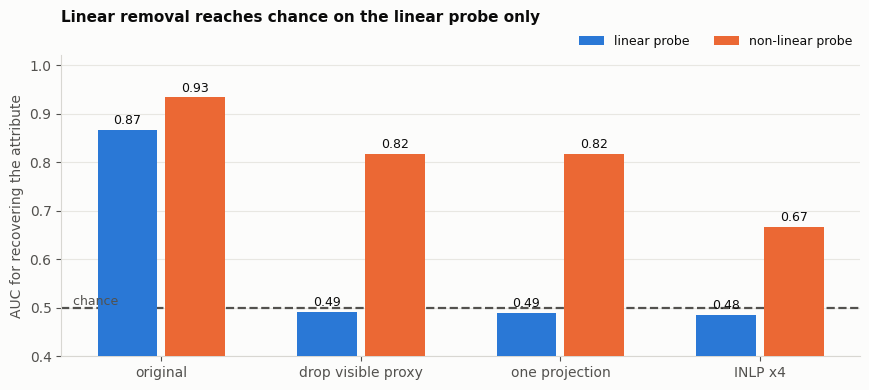

In [5]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

w0 = LogisticRegression(max_iter=2000).fit(X, z).coef_[0]
w0 /= np.linalg.norm(w0)
variants = [('original', X),
            ("drop visible proxy", X[:, [1, 2, 3]]),
            ('one projection', X - np.outer(X @ w0, w0)),
            (f'INLP x{step + 1}', P)]
lin = [probe(M, 'linear') for _, M in variants]
non = [probe(M, 'tree') for _, M in variants]

fig, ax = plt.subplots(figsize=(8.8, 4.0))
x = np.arange(len(variants))
ax.bar(x - 0.17, lin, 0.30, label='linear probe', color=BLUE, zorder=3)
ax.bar(x + 0.17, non, 0.30, label='non-linear probe', color=ORANGE, zorder=3)
for xi, (lv, nv) in zip(x, zip(lin, non)):
    ax.text(xi - 0.17, lv + 0.012, f'{lv:.2f}', ha='center', fontsize=9, color=INK)
    ax.text(xi + 0.17, nv + 0.012, f'{nv:.2f}', ha='center', fontsize=9, color=INK)
ax.axhline(0.5, color=MUTED, lw=1.6, ls='--')
ax.text(0.01, 0.5, ' chance', color=MUTED, fontsize=9, va='bottom', ha='left',
        transform=ax.get_yaxis_transform())
ax.set_xticks(x, [n for n, _ in variants])
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=False, ncol=2, fontsize=9, loc='lower right', bbox_to_anchor=(1.0, 1.0), borderaxespad=0.2)
tidy(ax, xgrid=False)
ax.set_ylabel('AUC for recovering the attribute')
ax.set_title('Linear removal reaches chance on the linear probe only',
             loc='left', pad=24)
fig.tight_layout()
plt.savefig('../figures/05_linear_vs_nonlinear.png', dpi=150, bbox_inches='tight')
plt.show()